In [45]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder



In [46]:
fc = pd.read_csv('fake_currency_data.csv')
currency = pd.DataFrame(fc)

currency.head()
    

,Country,Denomination,Counterfeit,SerialNumber,SecurityFeatures,Weight(mg),Length(mm),Width(mm),Thickness(mm)
0,USA,$100,Yes,25973198,Hologram,1.731759,130.243185,66.537999,0.098488
1,USA,$20,Yes,95903230,Security Thread,1.002179,152.596364,76.135834,0.094119
2,ZAR,R100,No,82937914,Hologram,2.306713,152.857126,66.772442,0.061393
3,USA,R200,Yes,23612989,Microprint,1.366965,143.133672,78.377052,0.053114
4,ZAR,R200,Yes,56025342,Watermark,1.796075,129.664777,75.916093,0.051438


In [47]:
currency =currency.rename(columns = {'Country':'CountryOfOrigin'})

currency.head()

,CountryOfOrigin,Denomination,Counterfeit,SerialNumber,SecurityFeatures,Weight(mg),Length(mm),Width(mm),Thickness(mm)
0,USA,$100,Yes,25973198,Hologram,1.731759,130.243185,66.537999,0.098488
1,USA,$20,Yes,95903230,Security Thread,1.002179,152.596364,76.135834,0.094119
2,ZAR,R100,No,82937914,Hologram,2.306713,152.857126,66.772442,0.061393
3,USA,R200,Yes,23612989,Microprint,1.366965,143.133672,78.377052,0.053114
4,ZAR,R200,Yes,56025342,Watermark,1.796075,129.664777,75.916093,0.051438


In [48]:
currency.describe(include = 'all')

,CountryOfOrigin,Denomination,Counterfeit,SerialNumber,SecurityFeatures,Weight(mg),Length(mm),Width(mm),Thickness(mm)
count,1000000,1000000,1000000,1.000000e+06,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
unique,3,12,2,NaN,4,NaN,NaN,NaN,NaN
top,UK,R50,No,NaN,Microprint,NaN,NaN,NaN,NaN
freq,333611,83769,500609,NaN,250365,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,5.502259e+07,NaN,1.649766,140.020542,70.003944,0.213846
std,NaN,NaN,NaN,2.598490e+07,NaN,0.490712,11.544293,5.772709,11.776348
min,NaN,NaN,NaN,1.000015e+07,NaN,0.800003,120.000073,60.000005,0.050000
25%,NaN,NaN,NaN,3.249784e+07,NaN,1.224855,130.034878,64.999762,0.062489
50%,NaN,NaN,NaN,5.506594e+07,NaN,1.649137,140.032496,70.008440,0.074996
75%,NaN,NaN,NaN,7.751115e+07,NaN,2.074540,150.022309,75.006372,0.087504


In [49]:
currency.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   CountryOfOrigin   1000000 non-null  str    
 1   Denomination      1000000 non-null  str    
 2   Counterfeit       1000000 non-null  str    
 3   SerialNumber      1000000 non-null  int64  
 4   SecurityFeatures  1000000 non-null  str    
 5   Weight(mg)        1000000 non-null  float64
 6   Length(mm)        1000000 non-null  float64
 7   Width(mm)         1000000 non-null  float64
 8   Thickness(mm)     1000000 non-null  float64
dtypes: float64(4), int64(1), str(4)
memory usage: 68.7 MB


In [50]:
currency.nunique()

CountryOfOrigin           3
Denomination             12
Counterfeit               2
SerialNumber         994439
SecurityFeatures          4
Weight(mg)          1000000
Length(mm)          1000000
Width(mm)           1000000
Thickness(mm)        999862
dtype: int64

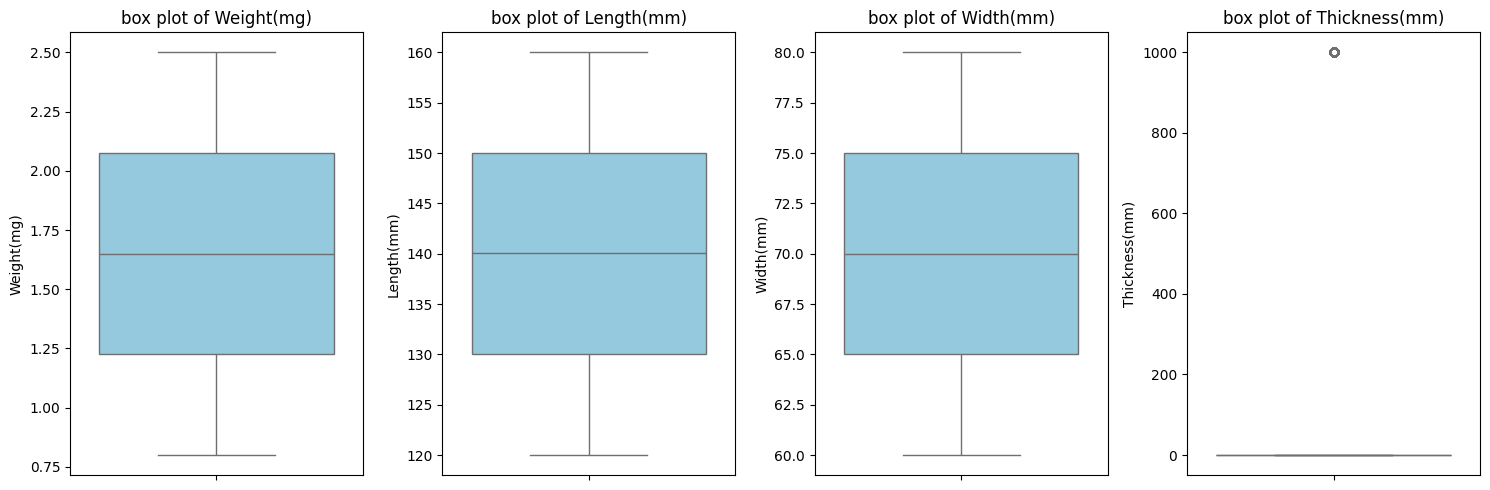

In [51]:

cols = ['Weight(mg)','Length(mm)','Width(mm)','Thickness(mm)']


fig,axes = plt.subplots(1,4, figsize=(15,5))

for i,col in enumerate(cols):
    sns.boxplot(y=currency[col], ax =axes[i], color ='skyblue')
    axes[i].set_title(f'box plot of {col}')

plt.tight_layout()
plt.show()

Here is a breakdown of the specific issues observed:

Extreme Outlier in Thickness: The "box plot of Thickness(mm)" shows a single data point at 1000, while the rest of the distribution is compressed near 0. This suggests a potential data entry error, as 1000mm (1 meter) is physically improbable compared to the other dimensions (Weight in mg, Length/Width in mm).

Highly Skewed/Compressed Distribution: Due to the scale of the outlier (1000), the main box for "Thickness(mm)" is flattened at the bottom of the y-axis. This makes it impossible to see the median, quartiles, or the actual spread of the typical thickness values.

Scale Inconsistency: While Weight, Length, and Width show healthy distributions with clearly visible interquartile ranges, the Thickness plot is rendered useless for analysis because the y-axis is stretched to accommodate the single outlier.

Recommendation: You should investigate the source of the 1000mm value. It is likely a typo (perhaps it should have been 1.0 or 10) or a placeholder value that needs to be removed or corrected before further analysis.



The data summary in image_9bfab8.png confirms that the outlier in "Thickness(mm)" is indeed the culprit behind the distorted box plot in image_9c0183.png.

Looking at the Thickness(mm) column in the summary table:

The Maximum Value: The max value is 999.000000, which is massive compared to the rest of the data.

The Normal Range: The 75% percentile is only 0.087504, and the mean is 0.213846. This proves that the vast majority of your currency notes are less than 0.1mm thick.

Standard Deviation: The std is 11.776348, which is incredibly high for this feature because that single 999 value is pulling the average away from the median (0.074996).

Since the 75th percentile is below 0.1, you should filter the data to remove any rows where thickness is far beyond a reasonable physical limit for a banknote.

In [52]:
# Create a cleaned dataframe by removing the extreme outlier
currency_clean = currency[currency['Thickness(mm)'] < 1.0]

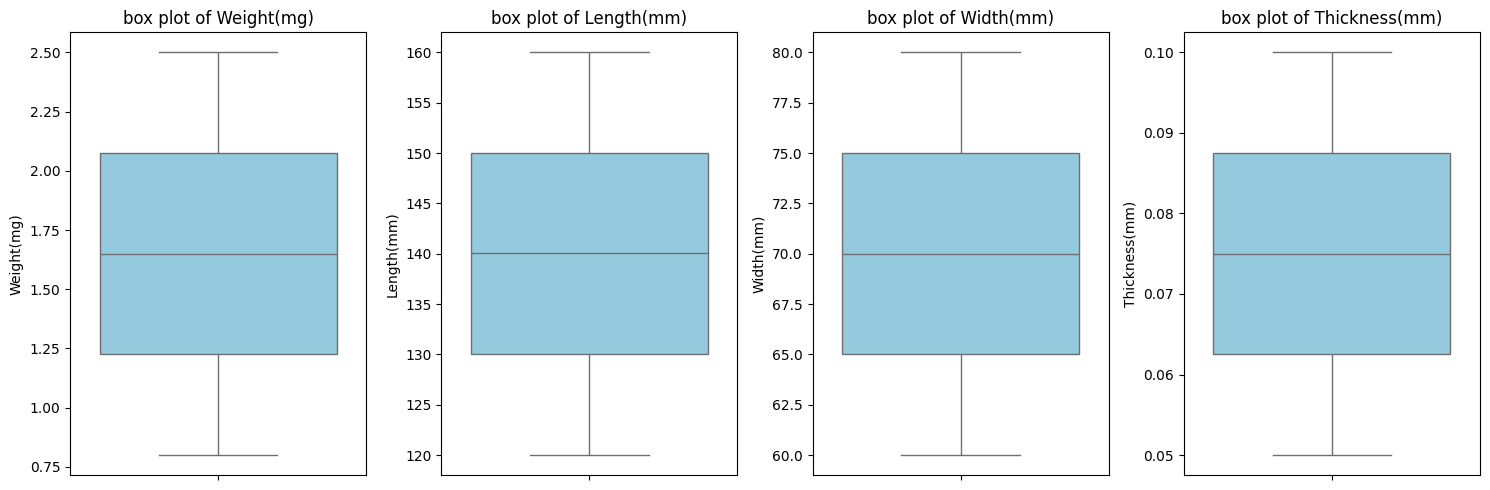

In [53]:

cols = ['Weight(mg)','Length(mm)','Width(mm)','Thickness(mm)']


fig,axes = plt.subplots(1,4, figsize=(15,5))

for i,col in enumerate(cols):
    sns.boxplot(y=currency_clean[col], ax =axes[i], color ='skyblue')
    axes[i].set_title(f'box plot of {col}')

plt.tight_layout()
plt.show()

In [54]:
# Option A: Select a specific number of samples (e.g., 10,000 rows)
currency_clean = currency_clean.sample(n=10000, replace=False, random_state=42)

# Option B: Select a fraction of the samples (e.g., 5% of the million rows)
# currency = currency.sample(frac=0.05, replace=False, random_state=42)

In [55]:
currency_clean.head()

,CountryOfOrigin,Denomination,Counterfeit,SerialNumber,SecurityFeatures,Weight(mg),Length(mm),Width(mm),Thickness(mm)
895838,USA,$5,No,43664000,Watermark,1.965975,126.473975,64.971619,0.071613
780207,USA,$20,Yes,36395729,Watermark,0.909662,124.820215,71.872402,0.054942
679063,UK,£10,No,33509743,Hologram,1.954759,154.049858,62.716239,0.076680
82877,USA,$10,No,16810525,Security Thread,1.860423,143.700854,68.024342,0.090603
562522,USA,$1,No,89465503,Watermark,2.059536,126.389270,68.181210,0.093254


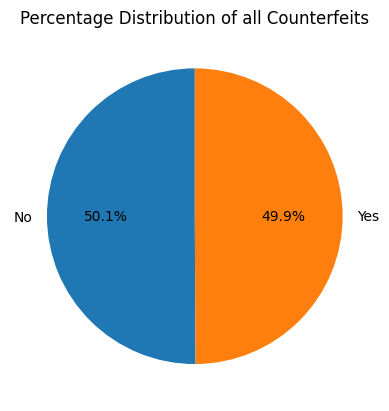

In [56]:
all_counterfeit = currency_clean['Counterfeit'].value_counts()

plt.pie(all_counterfeit.to_list(),labels=all_counterfeit.index,autopct = '%.1f%%', startangle=90)
plt.title('Percentage Distribution of all Counterfeits')
plt.show()

The data in the pie chart is nearly balanced by observation and no balancing is needed

Here is why:

Near-Perfect Split: The "Counterfeit" classes are split 50.1% ("No") and 49.9% ("Yes").

Statistical Significance: In machine learning, a dataset is considered "balanced" when the classes are represented roughly equally. A difference of 0.2% is statistically negligible, especially given that your total count is 1,000,000 samples.

Raw Counts: According to the summary table in image_9bfab8.png, the most frequent class ("No") appears 500,609 times out of 1,000,000. This confirms the "Yes" class has 499,391 samples—an incredibly healthy distribution for training a model.

In [57]:
print(f"Country of origin: {currency_clean['CountryOfOrigin'].unique()} \n")
print(f"Counterfeit: {currency_clean['Counterfeit'].unique()}\n")
print(f"Security Features: {currency_clean['SecurityFeatures'].unique()}\n")
print(f"Denomination: {currency_clean['Denomination'].unique()}\n")

Country of origin: <StringArray>
['USA', 'UK', 'ZAR']
Length: 3, dtype: str 

Counterfeit: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Security Features: <StringArray>
['Watermark', 'Hologram', 'Security Thread', 'Microprint']
Length: 4, dtype: str

Denomination: <StringArray>
[  '$5',  '$20',  '£10',  '$10',   '$1', 'R200', 'R100', '$100',  '$50',
  '£20',  'R50',   '£5']
Length: 12, dtype: str



In [58]:
label_Encoder = LabelEncoder()

currency_clean['Counterfeit'] = label_Encoder.fit_transform(currency_clean['Counterfeit'])


In [59]:
country_vectors = pd.get_dummies(currency_clean['CountryOfOrigin'], dtype=int)
security_vectors = pd.get_dummies(currency_clean['SecurityFeatures'], dtype=int)
demonimation_vectors =pd.get_dummies(currency_clean['Denomination'], dtype=int)
currency_clean_reduced = pd.concat([currency_clean, country_vectors, security_vectors,demonimation_vectors], axis = 1)

#It is important that the student drop the relevant columns after the vector space has been created or lose 1 mark
currency_clean_reduced.drop(['SecurityFeatures', 'CountryOfOrigin','Denomination'], axis = 1, inplace = True) 
currency_clean_reduced.head(10)

,Counterfeit,SerialNumber,Weight(mg),Length(mm),Width(mm),Thickness(mm),UK,USA,ZAR,Hologram,...,$100,$20,$5,$50,R100,R200,R50,£10,£20,£5
895838,0,43664000,1.965975,126.473975,64.971619,0.071613,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
780207,1,36395729,0.909662,124.820215,71.872402,0.054942,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
679063,0,33509743,1.954759,154.049858,62.716239,0.076680,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
82877,0,16810525,1.860423,143.700854,68.024342,0.090603,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
562522,0,89465503,2.059536,126.389270,68.181210,0.093254,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
509115,1,90111927,1.116627,144.865812,78.764817,0.061276,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
971745,0,96406734,1.918048,153.644278,68.813334,0.065923,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
79614,1,19660722,1.317400,132.729465,60.858666,0.093297,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
173562,1,90597708,1.702605,148.568676,79.253189,0.089255,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
321480,1,39698624,1.833663,159.275753,62.519363,0.057743,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [62]:
currency_clean_reduced.dtypes

Counterfeit          int64
SerialNumber         int64
Weight(mg)         float64
Length(mm)         float64
Width(mm)          float64
Thickness(mm)      float64
UK                   int64
USA                  int64
ZAR                  int64
Hologram             int64
Microprint           int64
Security Thread      int64
Watermark            int64
$1                   int64
$10                  int64
$100                 int64
$20                  int64
$5                   int64
$50                  int64
R100                 int64
R200                 int64
R50                  int64
£10                  int64
£20                  int64
£5                   int64
dtype: object

In [60]:
from sklearn.model_selection import train_test_split

X = currency_clean_reduced.drop(['Counterfeit'], axis = 1)
y = currency_clean_reduced['Counterfeit'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 13)

#The input data needs to be scaled, 
#but to avoid data leakage the train and test data needs to be scaled separately
#Lose 3 marks if the data is not scaled
#Lose 2 marks if the data is first scaled and then split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
scaler.fit(X_test)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8000, 24)
(8000,)
(2000, 24)
(2000,)


NB(acc): 0.493000 (0.012459)
NB(f1): 0.492658 (0.012265)


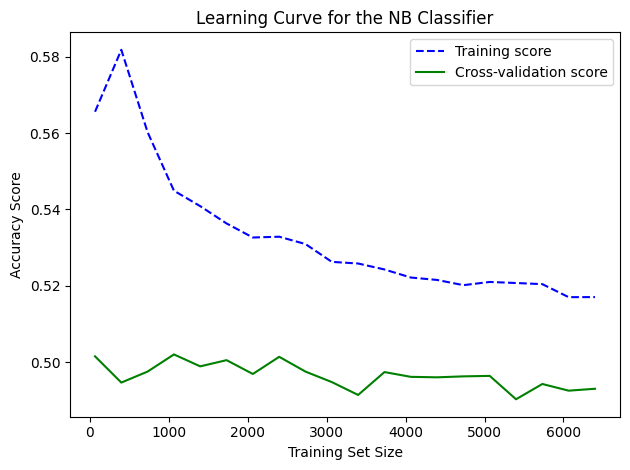

LR(acc): 0.484625 (0.010012)
LR(f1): 0.483746 (0.010490)


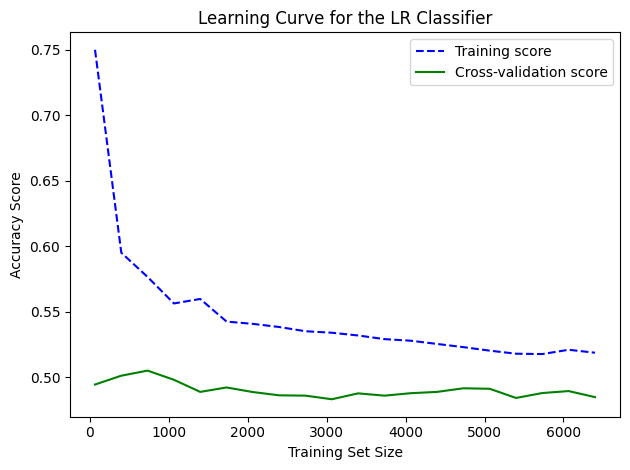

SVM(acc): 0.495500 (0.005908)
SVM(f1): 0.495205 (0.005849)


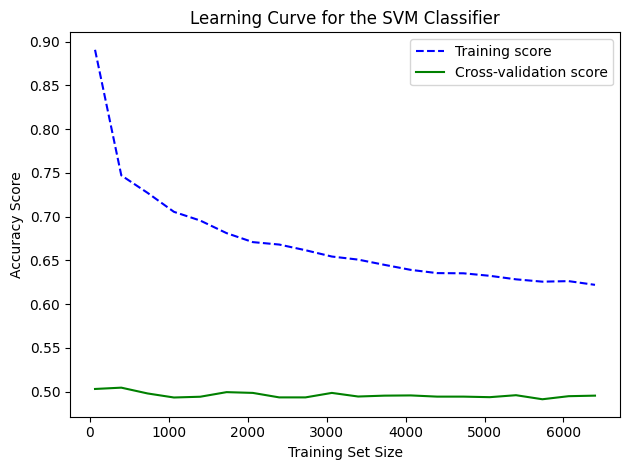

In [61]:
#Lose 1 mark for every library that is imported and not used by the student (lose max 3 marks)
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer

models = []

models.append(('NB', GaussianNB()))
models.append(('LR', LogisticRegression()))
models.append(('SVM', SVC(gamma = 'auto')))

results = []
names = []

f1 = make_scorer(f1_score, average='weighted')

for name, model in models:
    kfold = KFold(n_splits = 5, random_state = 13, shuffle = True)
    cv_results = cross_val_score(model, X_train, y_train, cv = kfold, scoring = 'accuracy')
    results.append(cv_results)
    names.append(name)
    msg = '%s(acc): %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)
    cv_results = cross_val_score(model, X_train, y_train, cv = kfold, scoring = f1)
    results.append(cv_results)
    names.append(name)
    msg = '%s(f1): %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)
    train_sizes, train_scores, validation_scores = learning_curve(estimator = model,
                                                              X = X_train,
                                                              y = y_train,
                                                              train_sizes = np.linspace(0.01, 1.0, 20),
                                                              cv = kfold,
                                                              scoring = 'accuracy', shuffle = True)
    mean_training = np.mean(train_scores, axis=1)
    mean_testing = np.mean(validation_scores, axis=1)

    plt.plot(train_sizes, mean_training, '--', color = "b",  label = "Training score")
    plt.plot(train_sizes, mean_testing, color = "g", label = "Cross-validation score")
    plt.title(f"Learning Curve for the " + name + " Classifier")
    plt.xlabel("Training Set Size"), plt.ylabel("Accuracy Score"), plt.legend(loc = "best")
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

model = SVC(gamma = 'auto')
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(metrics.accuracy_score(predictions, y_test))
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))